In [1]:
import pandas as pd

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

In [5]:
df["age"]=2026-df["Year_Birth"]

In [6]:
df['Total_Spending']=df['MntWines']+df["MntFruits"]+df['MntMeatProducts']+df['MntFishProducts']+df['MntSweetProducts']+df['MntGoldProds']

In [7]:
df['Total_Children']=df['Kidhome']+df['Teenhome']

In [8]:
df_cleaned=df.drop(["ID",'Year_Birth','Dt_Customer','Kidhome','Teenhome','MntWines','MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds',],axis=1)

In [9]:
df_cleaned.head()

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Total_Spending,Total_Children
0,Graduation,Single,58138.0,58,3,8,10,4,7,0,1,69,1617,0
1,Graduation,Single,46344.0,38,2,1,1,2,5,0,0,72,27,2
2,Graduation,Together,71613.0,26,1,8,2,10,4,0,0,61,776,0
3,Graduation,Together,26646.0,26,2,2,0,4,6,0,0,42,53,1
4,PhD,Married,58293.0,94,5,5,3,6,5,0,0,45,422,1


In [10]:
map_martial={'Absurd':'Single',"Alone":"Single","Divorced":"Single","Widow":'Single','YOLO':'Single','Together':'Married'}


In [11]:
df_cleaned["Marital_Status"]=df_cleaned["Marital_Status"].replace({'Absurd':'Single',"Alone":"Single","Divorced":"Single","Widow":'Single','YOLO':'Single','Together':'Married','Single':'Single','Married':"Married"})
df_cleaned["Education"]=df_cleaned["Education"].replace({"Graduation":'Graduate',"Basic":'Undergraduate',"2n Cycle":"Undergraduate","Master":'Postgraduate',"PhD":"Postgraduate"})


In [12]:
df_edu = pd.get_dummies(df_cleaned["Education"], dtype=int)
df_mst = pd.get_dummies(df_cleaned["Marital_Status"], dtype=int)


In [13]:
df_mst.head()

,Married,Single
0,0,1
1,0,1
2,1,0
3,1,0
4,1,0


In [14]:
df_cleaned.columns

Index(['Education', 'Marital_Status', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'age', 'Total_Spending',
       'Total_Children'],
      dtype='object')

In [15]:
df_cleaned.Income=df.Income.fillna(df.Income.median())

In [16]:
df['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [17]:
df_cleaned.isnull().sum()

Education              0
Marital_Status         0
Income                 0
Recency                0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
age                    0
Total_Spending         0
Total_Children         0
dtype: int64

In [18]:
temp_df = pd.concat([df_cleaned.drop(['Education','Marital_Status'],axis=1), df_edu],axis=1)
new_df = pd.concat([temp_df, df_mst],axis=1)


In [19]:
new_df.columns

Index(['Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'age', 'Total_Spending', 'Total_Children',
       'Graduate', 'Postgraduate', 'Undergraduate', 'Married', 'Single'],
      dtype='object')

In [20]:
df_processed=new_df.copy()

In [21]:
df_processed.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Total_Spending,Total_Children,Graduate,Postgraduate,Undergraduate,Married,Single
0,58138.0,58,3,8,10,4,7,0,1,69,1617,0,1,0,0,0,1
1,46344.0,38,2,1,1,2,5,0,0,72,27,2,1,0,0,0,1
2,71613.0,26,1,8,2,10,4,0,0,61,776,0,1,0,0,1,0
3,26646.0,26,2,2,0,4,6,0,0,42,53,1,1,0,0,1,0
4,58293.0,94,5,5,3,6,5,0,0,45,422,1,0,1,0,1,0


In [23]:
df_processed.shape

(2240, 17)

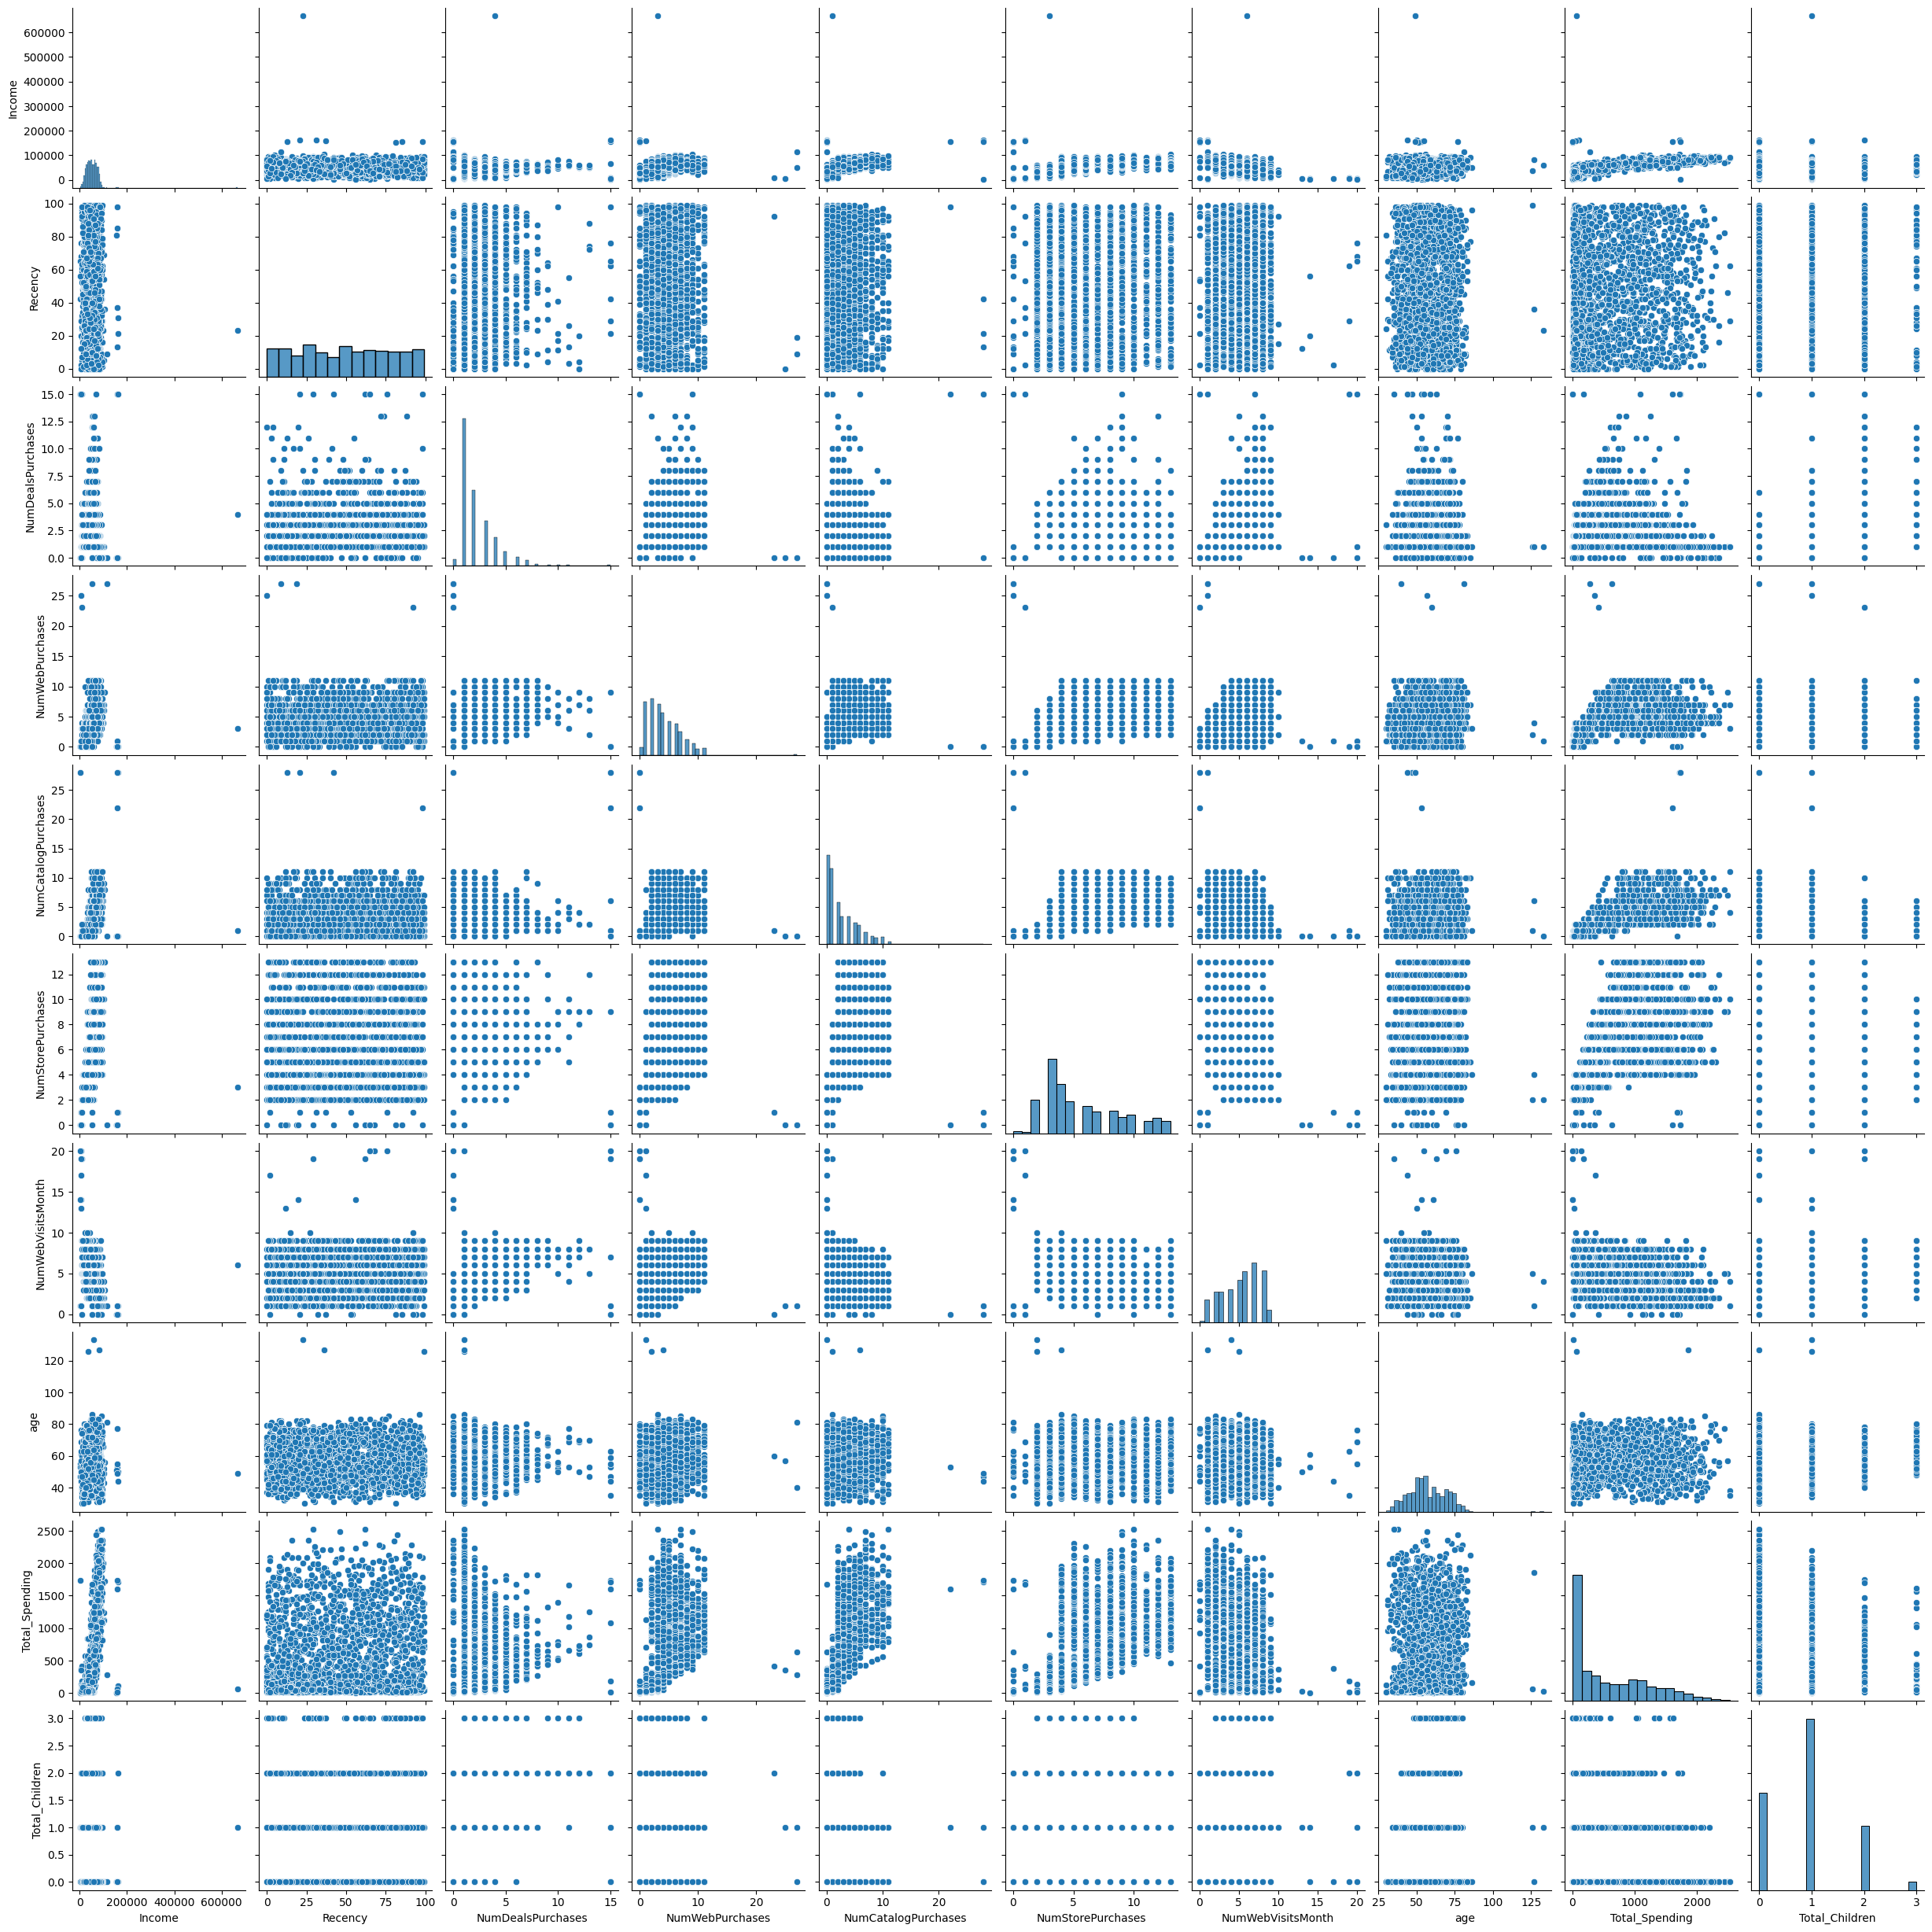

In [28]:
sns.pairplot(df_cleaned[['Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'age', 'Total_Spending', 'Total_Children',]])

In [41]:
df_temp=df_processed[(df_processed['Income']<600000)&(df_processed['age']<100)]

In [42]:
df_temp['age'].max()

np.int64(86)

In [43]:
df_processed=df_temp.copy()

In [56]:
corr=df_processed[['Income', 'Recency', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'age', 'Total_Spending', 'Total_Children',]].corr()

<Axes: >

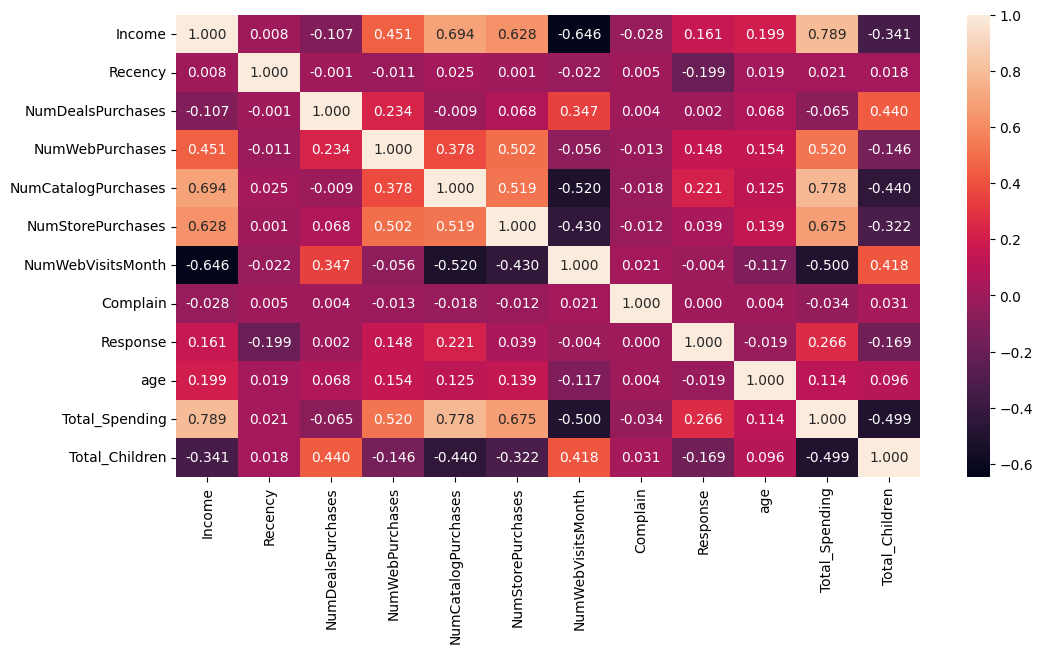

In [57]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    corr,
    annot=True,
    ax=ax,
    fmt='.3f'
)

Scaling

In [58]:
from sklearn.preprocessing import StandardScaler

In [59]:
scaler=StandardScaler()
X=df_processed

In [61]:
x_scaled=scaler.fit_transform(X)

In [63]:
from sklearn.decomposition import PCA

In [64]:
pca = PCA(n_components=2)

In [73]:
x_pca = pca.fit_transform(x_scaled)

In [74]:
x_pca.shape

(2236, 2)

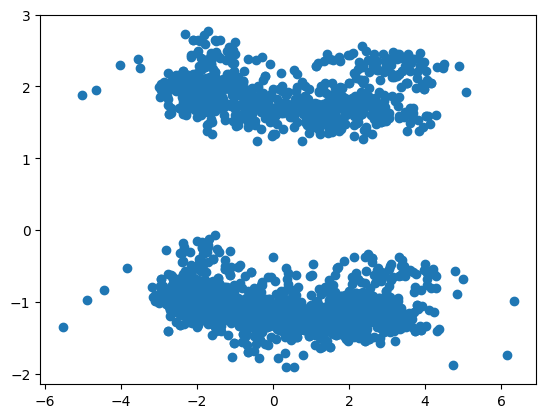

In [76]:
plt.scatter(x_pca[:,0],x_pca[:,1])

In [78]:
pca.explained_variance_ratio_

array([0.24502203, 0.12049884])

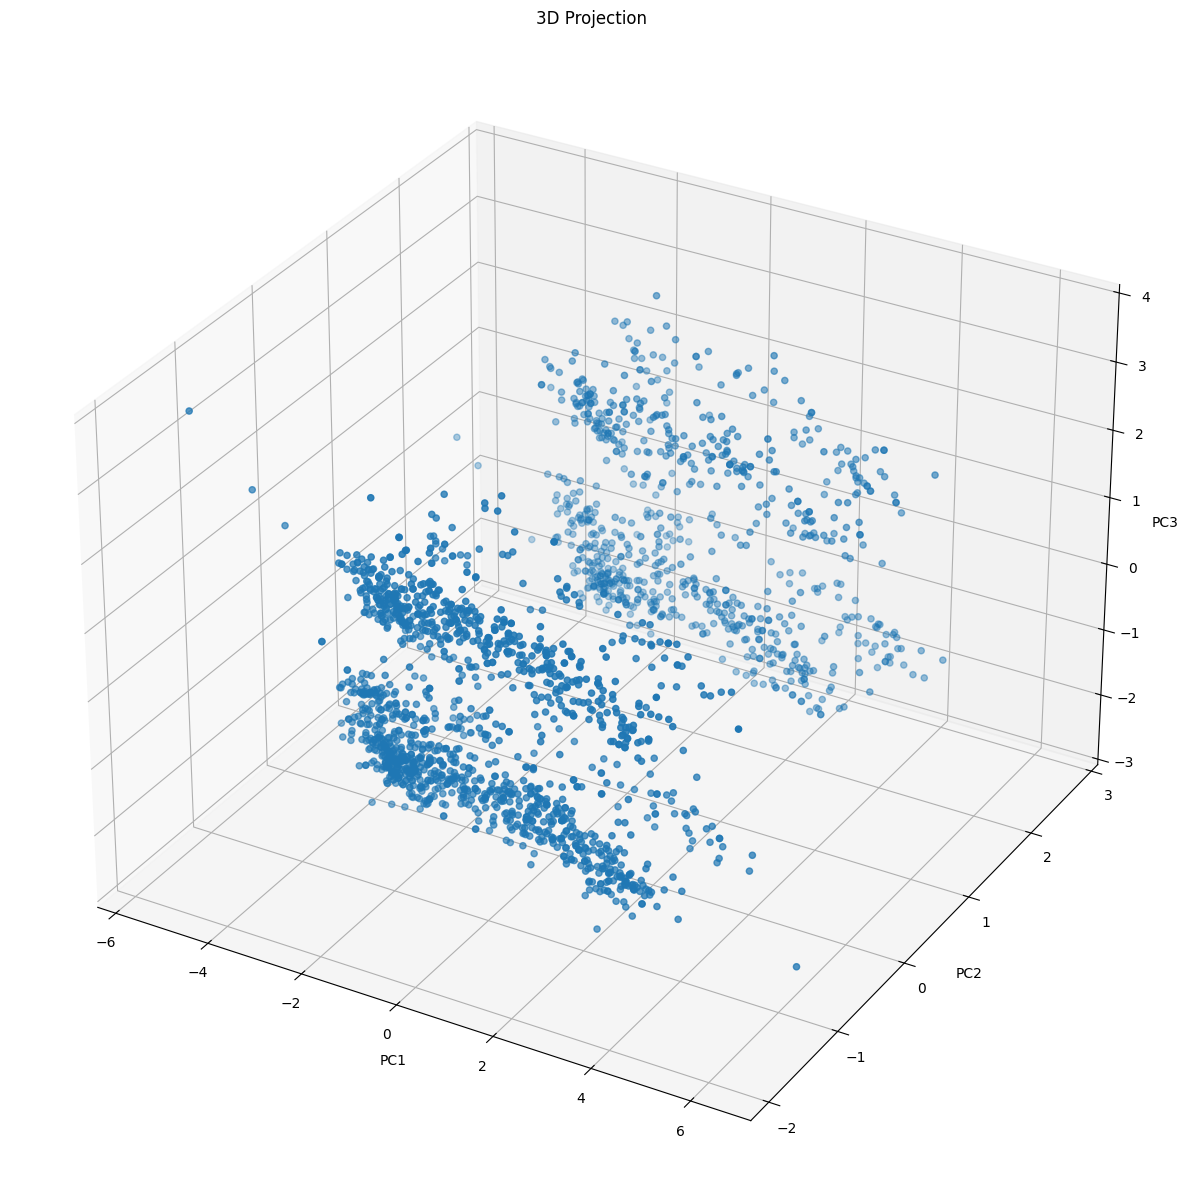

In [86]:
fig = plt.figure(figsize=(15,20))
ax = fig.add_subplot(111, projection='3d')
X_pca = PCA(n_components=3).fit_transform(x_scaled)
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title('3D Projection')
plt.show() 

In [87]:
from sklearn.cluster import KMeans

In [107]:
k_range=range(1,11)
wcss=[]
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(x_pca)
    wcss.append(kmeans.inertia_)


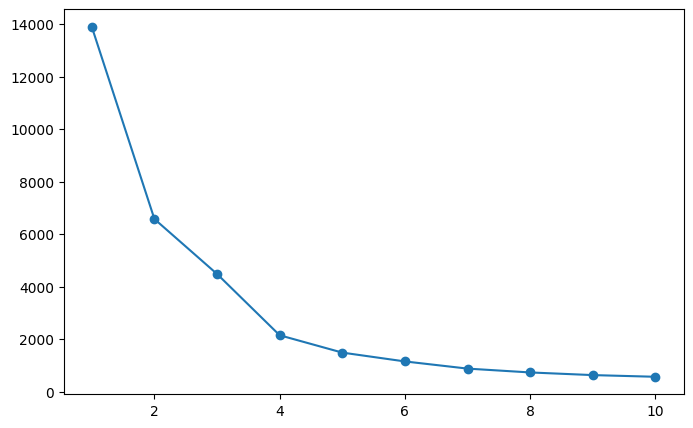

In [108]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o')

In [93]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [94]:
from kneed import KneeLocator


4


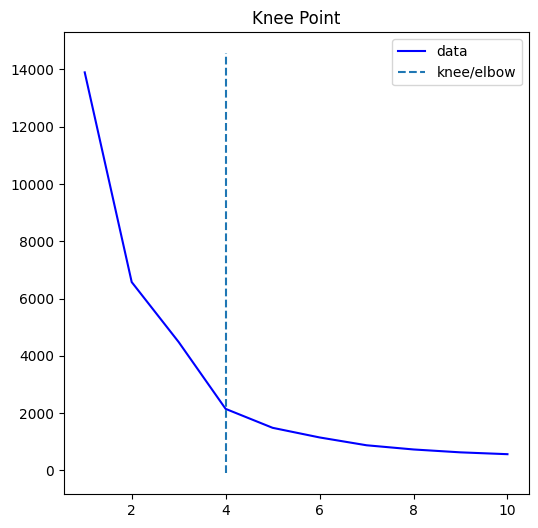

In [109]:
kl = KneeLocator(k_range, wcss, curve="convex", direction="decreasing")
print(kl.knee)
kl.plot_knee()


In [99]:
from sklearn.metrics import silhouette_score


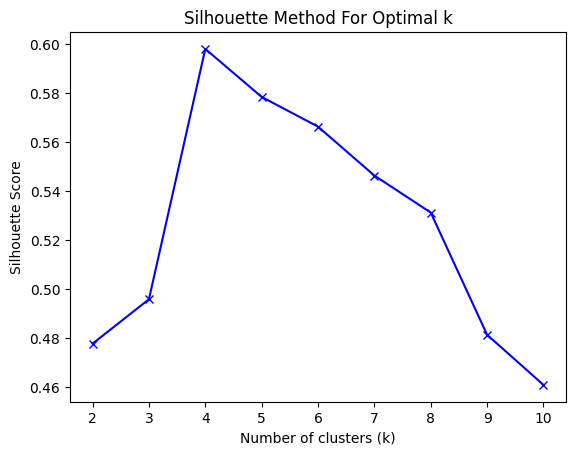

In [110]:
sil_scores=[]
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(x_pca)
    score = silhouette_score(x_pca, labels)
    sil_scores.append(score)

# Plotting the scores
plt.plot(range(2, 11), sil_scores,'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method For Optimal k')
plt.show()

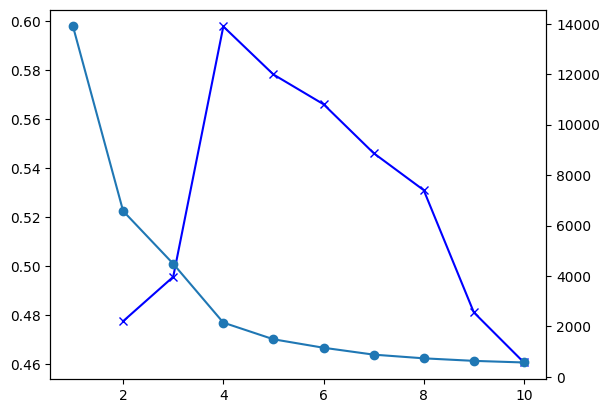

In [117]:
fig, ax = plt.subplots()
ax.plot(range(2, 11), sil_scores,'-bx')
ax1=ax.twinx()
ax1.plot(k_range, wcss, marker='o')

In [118]:
kmeans = KMeans(n_clusters=4)
labels_kmeans=kmeans.fit_predict(x_pca)

In [119]:
labels_kmeans

array([0, 3, 1, ..., 0, 1, 2], dtype=int32)

Text(0.5, 0, 'PC3')

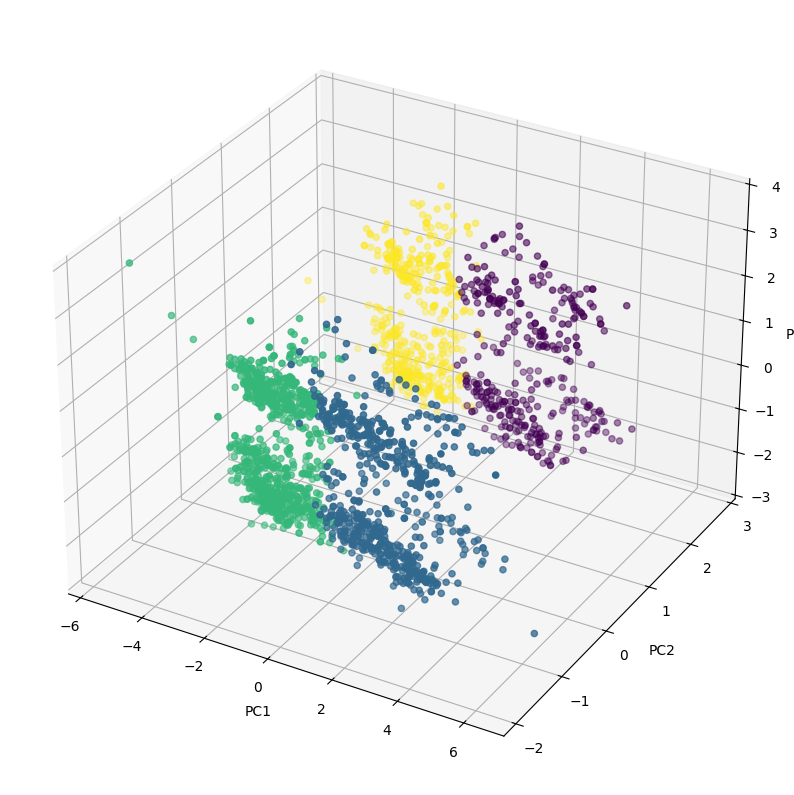

In [128]:
fig = plt.figure(figsize=(10,15))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],c=labels_kmeans)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')

In [125]:
from sklearn.cluster import AgglomerativeClustering

Text(0.5, 0, 'PC3')

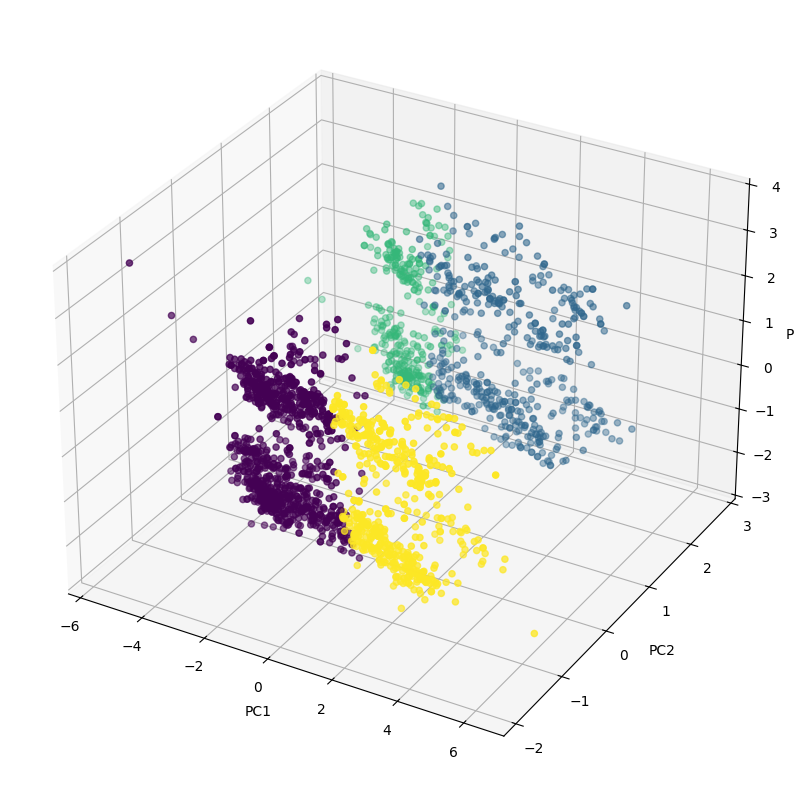

In [127]:
agg_clustering_model = AgglomerativeClustering(n_clusters=4, linkage='ward')
agg_labels = agg_clustering_model.fit_predict(x_pca)
fig = plt.figure(figsize=(10,15))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],c=agg_labels)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')

In [132]:
from scipy.cluster.hierarchy import dendrogram,linkage

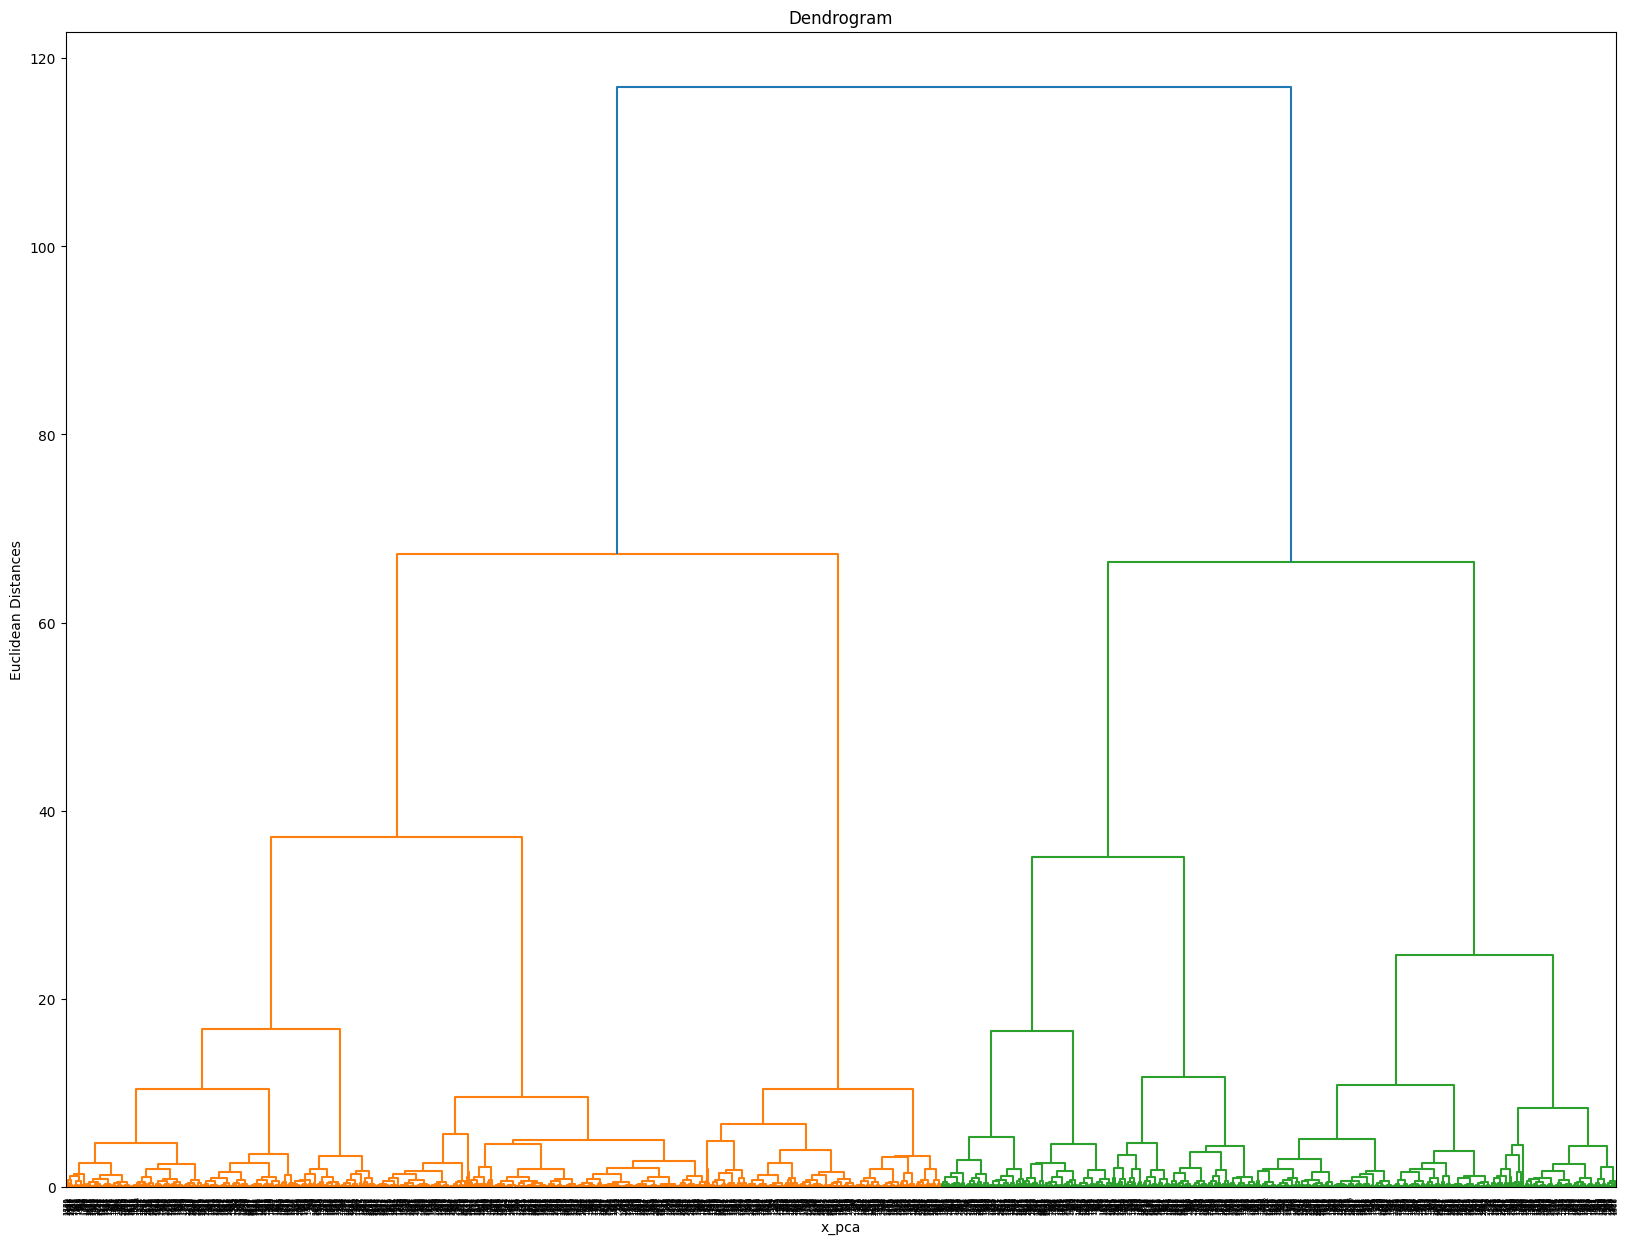

In [136]:
linked = linkage(x_pca, method='ward')

plt.figure(figsize=(20, 15))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram')
plt.xlabel('x_pca')
plt.ylabel('Euclidean Distances')
plt.show()

In [137]:
df_processed['cluster']=agg_labels

In [138]:
df_processed.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Total_Spending,Total_Children,Graduate,Postgraduate,Undergraduate,Married,Single,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,1617,0,1,0,0,0,1,1
1,46344.0,38,2,1,1,2,5,0,0,72,27,2,1,0,0,0,1,2
2,71613.0,26,1,8,2,10,4,0,0,61,776,0,1,0,0,1,0,3
3,26646.0,26,2,2,0,4,6,0,0,42,53,1,1,0,0,1,0,0
4,58293.0,94,5,5,3,6,5,0,0,45,422,1,0,1,0,1,0,0


<Axes: xlabel='Total_Spending', ylabel='Income'>

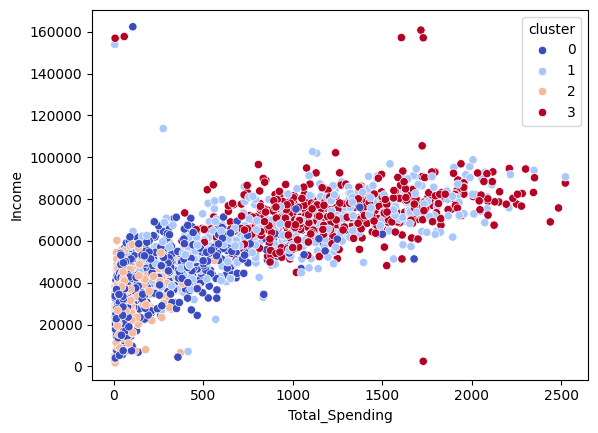

In [147]:
sns.scatterplot(data=df_processed, x="Total_Spending", y="Income",hue='cluster',palette='coolwarm')

<Axes: xlabel='cluster', ylabel='count'>

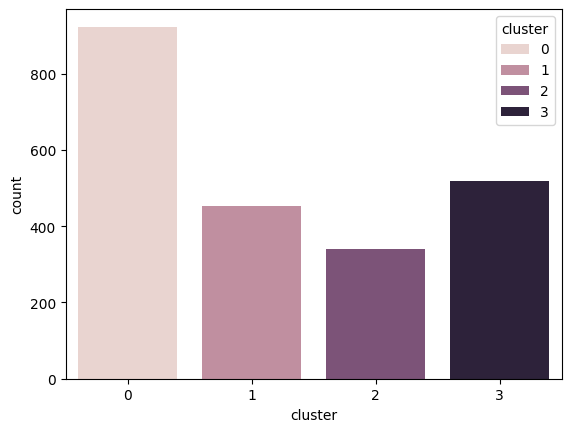

In [150]:
sns.countplot(x="cluster", data=df_processed,hue='cluster')

In [154]:
df_profile=df_processed.groupby('cluster').mean()

In [155]:
df_profile

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Total_Spending,Total_Children,Graduate,Postgraduate,Undergraduate,Married,Single
cluster,,,,,,,,,,,,,,,,,
0,39874.320152,49.482124,2.660888,3.146262,0.991333,4.175515,6.356446,0.010834,0.075840,55.847237,225.773564,1.255688,0.484290,0.367281,0.148429,1.0,0.0
1,66160.142070,49.759912,2.224670,5.568282,4.328194,7.830396,4.242291,0.004405,0.286344,59.449339,1018.766520,0.605727,0.522026,0.407489,0.070485,0.0,1.0
2,33300.586765,48.582353,2.297059,2.117647,0.520588,3.026471,6.729412,0.014706,0.135294,53.917647,91.361765,1.317647,0.502941,0.347059,0.150000,0.0,1.0
3,73223.783237,48.252408,1.838150,5.757225,5.583815,8.710983,3.491329,0.005780,0.169557,59.366089,1258.215800,0.470135,0.522158,0.410405,0.067437,1.0,0.0
